<div style=" padding:5px; border-radius:2.5px;">
<h1>Task 3:  Customer Churn Prediction (Bank Customers)</h1><h3>Dataset(Churn_Modelling.csv)</h3>
<div>
<p>According to given instruction, I have to <li>Clean and prepare the dataset.</li>
<li>Encode categorical features such as geography and gender.</li>
<li>Train a classification model.</li>
<li>Analyze feature importance to understand what influences churn.</li>
</div>
<div><p style="font-size:18px;"><h2>Summary</h2>
The objective of this task is to build a machine learning classification model that predicts whether a bank customer will leave the bank or stay. This is a real-world business problem used by banks to improve customer retention strategies.</p>
</div>
</div>

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
#loan dataset and describing basic structure of it.
df=pd.read_csv("Churn_Modelling.csv")
print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nFirst 5 Rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())

Shape of Dataset:
(10000, 14)

Column Names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3     

## Cleaning the Dataset

In [2]:
# Removing unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
# Checking missing values
df.isnull().sum().sort_values(ascending=False)

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Exited column is taken as a target variable to  predicts whether a bank customer will leave the bank (Exited = 1) or stay (Exited = 0).

In [ ]:
# Seperating features and target variables
X = df.drop("Exited", axis=1)   # or your target column
y = df["Exited"]

In [ ]:
# Identifying column types: categorical for text data and numeric for numbers
cat_features = ["Geography", "Gender"]
num_features = [col for col in X.columns if col not in cat_features]

## Preprocessing

In [ ]:
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first"), cat_features)
])

Now numbers will be scaled(0 mean, unit variance) and categorical will be converted into binary columns

## Pipeline

In [16]:
# Random Forest Pipeline with SMOTE
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

## Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

## Model Training

In [ ]:
# Spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5,scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)

## Predictions

In [ ]:

y_pred = rf_grid.predict(X_test)
y_prob = rf_grid.predict_proba(X_test)[:, 1]

## Evaluation

In [ ]:

print("Best Parameters:", rf_grid.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Accuracy: 0.8375
ROC-AUC: 0.8588002486307571

Confusion Matrix:
 [[1405  188]
 [ 137  270]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90      1593
           1       0.59      0.66      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



The Random Forest model achieved an accuracy of 83.75% and a ROC-AUC score of 0.86, showing good overall performance in predicting customer exit behavior. The confusion matrix indicates that most customers were classified correctly, including 1405 non-exited and 270 exited customers. The classification report shows strong performance for non-exited customers and moderate performance for exited customers, with the model correctly identifying about 66% of customers who exited the bank.

## Feature Importance

In [23]:
best_rf = rf_grid.best_estimator_
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get importance values from model
importances = best_rf.named_steps["model"].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                   Feature  Importance
1                 num__Age    0.299304
4       num__NumOfProducts    0.191935
8   cat__Geography_Germany    0.120783
10        cat__Gender_Male    0.089538
3             num__Balance    0.085222
6      num__IsActiveMember    0.044613
9     cat__Geography_Spain    0.043331
2              num__Tenure    0.040646
7     num__EstimatedSalary    0.040604
0         num__CreditScore    0.037459


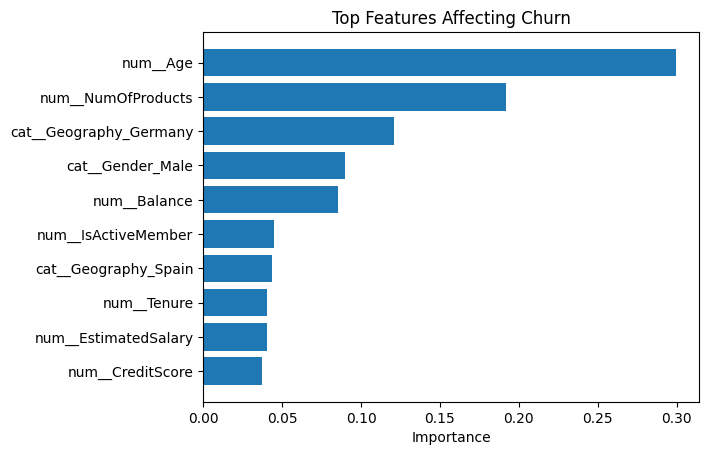

In [20]:
top_features = feature_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Features Affecting Churn")
plt.xlabel("Importance")
plt.show()

Feature importance shows which features have the greatest influence on predicting whether a customer will exit the bank. In the Random Forest model, features with higher importance values contribute more to the prediction decision. This helps identify the key factors affecting customer exit behavior, such as age, balance, or account activity.